In [ ]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign.csv to marketing_campaign.csv


In [ ]:
import pandas as pd

df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [ ]:
df['Age'] = 2026 - df['Year_Birth']

df['TotalSpending'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

In [ ]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
df = df[df['Income'] > 0]

In [ ]:
edu_map = {'Basic':0, 'Graduation':1, 'Master':2, 'PhD':3}
df['Education'] = df['Education'].map(edu_map)

top4 = df['Marital_Status'].value_counts().head(4).index
df['Marital_Status'] = df['Marital_Status'].apply(lambda x: x if x in top4 else 'Other')

df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)

In [ ]:
features_reg = ['Income', 'Age', 'Education', 'TotalChildren'] + \
               [c for c in df.columns if 'Marital_' in c]

X = df[features_reg].copy()
y = df['TotalSpending']

# 🔥 FIX NaN completely
X = X.fillna(X.median(numeric_only=True))
y = y.fillna(y.median())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models_reg = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

results = []

for name, model in models_reg.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results.append([name, mse, rmse, r2])

pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2"])

,Model,MSE,RMSE,R2
0,Linear Regression,0.117179,0.342313,0.078693
1,Ridge Regression,0.117181,0.342317,0.078677
2,Decision Tree,0.113614,0.337067,0.106718


In [ ]:
features_cls = features_reg

X = df[features_cls].copy()
y = df['Response']

X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models_cls = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models_cls.items():
    print("\n====================", name, "====================")

    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    print(classification_report(y_test, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))


==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       0.93      0.61      0.74       381
           1       0.25      0.73      0.37        67

    accuracy                           0.63       448
   macro avg       0.59      0.67      0.56       448
weighted avg       0.83      0.63      0.68       448

Confusion Matrix:
 [[234 147]
 [ 18  49]]

==================== KNN ====================
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       381
           1       0.42      0.21      0.28        67

    accuracy                           0.84       448
   macro avg       0.65      0.58      0.59       448
weighted avg       0.81      0.84      0.82       448

Confusion Matrix:
 [[362  19]
 [ 53  14]]

==================== Random Forest ====================
              precision    recall  f1-score   support

           0       0.87      0.95      0

In [ ]:
cluster_features = ['Income', 'TotalSpending', 'Age', 'TotalChildren']

Xc = df[cluster_features].copy()
Xc = Xc.fillna(Xc.median(numeric_only=True))

In [ ]:
scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc)

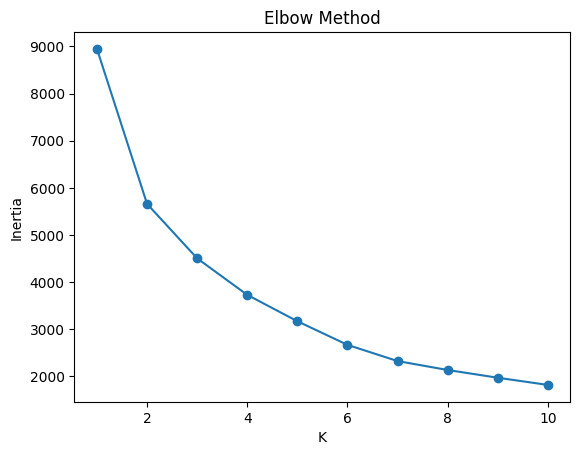

In [ ]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Xc_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(Xc_scaled)

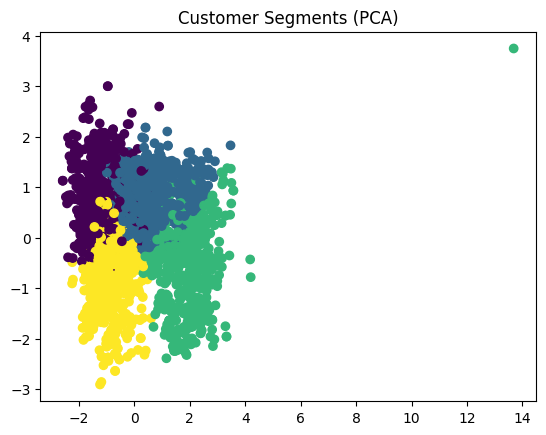

In [ ]:
pca = PCA(n_components=2)
components = pca.fit_transform(Xc_scaled)

plt.scatter(components[:,0], components[:,1], c=df['Cluster'])
plt.title("Customer Segments (PCA)")
plt.show()

In [ ]:
df.groupby('Cluster')[cluster_features].mean()

,Income,TotalSpending,Age,TotalChildren
Cluster,,,,
0,44108.534934,222.812227,60.589520,2.115721
1,61336.053082,802.909247,69.142123,0.688356
2,78094.845572,1434.786177,51.498920,0.285097
3,33678.734290,163.654372,48.846995,0.852459
